# Modern NFL Draft Value Chart & Chicago Bears Audit

A data-driven critique of the Jimmy Johnson draft value chart, applied to 21 years of Chicago Bears draft history.

**Author:** [Your name]  
**Data:** nfl_data_py (nflverse public data), 2000-2020 NFL drafts  
**Goal:** Build a modern pick value curve from career outcomes, then audit Bears drafting performance against it.

## Setup

In [1]:
import nfl_data_py as nfl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Bears colors for plotting consistency
BEARS_NAVY = '#0B162A'
BEARS_ORANGE = '#C83803'

## 1. Data: 21 Years of NFL Draft Picks

We pull every draft pick from 2000 through 2020. The 2020 cutoff is intentional — players need roughly 4-5 NFL seasons to accumulate meaningful career value, so including more recent classes would systematically penalize them.

In [2]:
# Pull all draft picks from 2000-2020
draft = nfl.import_draft_picks(list(range(2000, 2021)))

print(f"Total picks: {len(draft)}")
print(f"Years covered: {draft['season'].min()} to {draft['season'].max()}")
print(f"\nPicks per year (sanity check, should be ~250-262):")
print(draft['season'].value_counts().sort_index().to_string())

Total picks: 5350
Years covered: 2000 to 2020

Picks per year (sanity check, should be ~250-262):
2000    254
2001    246
2002    261
2003    262
2004    255
2005    255
2006    255
2007    255
2008    252
2009    256
2010    255
2011    254
2012    253
2013    254
2014    256
2015    256
2016    253
2017    253
2018    256
2019    254
2020    255


## 2. Building a Career Value Metric

The dataset doesn't include Pro Football Reference's Approximate Value (AV), so we build a position-agnostic metric from raw inputs available for every player:

- **Seasons started** (1 point each): a baseline NFL contributor
- **Pro Bowls** (2 points each): recognition of being good at position
- **All-Pros** (4 points each): top-of-position honor

Weights are a judgment call. The smell test is whether the resulting top-20 leaderboard contains the era's consensus greats — Brady, Donald, Wagner, Zack Martin, Joe Thomas, Rodgers, Trent Williams. It does.

In [3]:
# Fill missing values with 0 (e.g., a player with no Pro Bowls has a null, treat as 0)
for col in ['seasons_started', 'probowls', 'allpro', 'games']:
    draft[col] = draft[col].fillna(0)

# Build the composite career value score
draft['career_value'] = (
    draft['seasons_started'] * 1
    + draft['probowls'] * 2
    + draft['allpro'] * 4
)

# Smell test: top 20 careers by this metric
top20 = draft.nlargest(20, 'career_value')
print("Top 20 careers, 2000-2020 drafts (smell test for our metric):")
print(top20[['season', 'pick', 'pfr_player_name', 'position', 
             'seasons_started', 'probowls', 'allpro', 'career_value']].to_string(index=False))

Top 20 careers, 2000-2020 drafts (smell test for our metric):
 season  pick  pfr_player_name position  seasons_started  probowls  allpro  career_value
   2000   199        Tom Brady       QB               21        15       3            63
   2014    13     Aaron Donald       DT               10        10       8            62
   2012    47     Bobby Wagner       LB               14        10       6            58
   2014    16      Zack Martin        G               11         9       7            57
   2007     3       Joe Thomas        T               10        10       6            54
   2005    24    Aaron Rodgers       QB               16        10       4            52
   2010     4   Trent Williams        T               15        12       3            51
   2011   191      Jason Kelce        C               12         7       6            50
   2013    63     Travis Kelce       TE               12        11       4            50
   2001    32       Drew Brees       QB         

## 3. Fitting the Modern Value Curve

For every pick number 1-262, we compute the mean career value across all 21 drafts. We then fit an exponential decay function to the resulting distribution. Exponential decay matches the observed shape: fast drop early, leveling off in the late rounds.

In [4]:
# Average career value at each pick number
pick_value = draft.groupby('pick')['career_value'].agg(['mean', 'median', 'count']).reset_index()

# Fit exponential decay
def decay_curve(x, a, b, c):
    return a * np.exp(-b * x) + c

x_data = pick_value['pick'].values
y_data = pick_value['mean'].values
params, _ = curve_fit(decay_curve, x_data, y_data, p0=[15, 0.02, 1])
a, b, c = params

print(f"Fitted curve: value = {a:.2f} * exp(-{b:.4f} * pick) + {c:.2f}")
print("\nExpected career value at key pick numbers:")
for p in [1, 5, 10, 15, 20, 32, 50, 75, 100, 150, 200, 250]:
    print(f"  Pick {p:>3}: {decay_curve(p, a, b, c):.2f}")

Fitted curve: value = 13.30 * exp(-0.0219 * pick) + 0.90

Expected career value at key pick numbers:
  Pick   1: 13.90
  Pick   5: 12.81
  Pick  10: 11.58
  Pick  15: 10.47
  Pick  20: 9.48
  Pick  32: 7.50
  Pick  50: 5.35
  Pick  75: 3.47
  Pick 100: 2.39
  Pick 150: 1.40
  Pick 200: 1.06
  Pick 250: 0.95


## 4. Comparison to the Jimmy Johnson Chart

The Jimmy Johnson chart, built in the early 1990s based on trade norms of the era, still anchors NFL trade discussions today. Compared to actual career outcomes, it severely overvalues top picks.

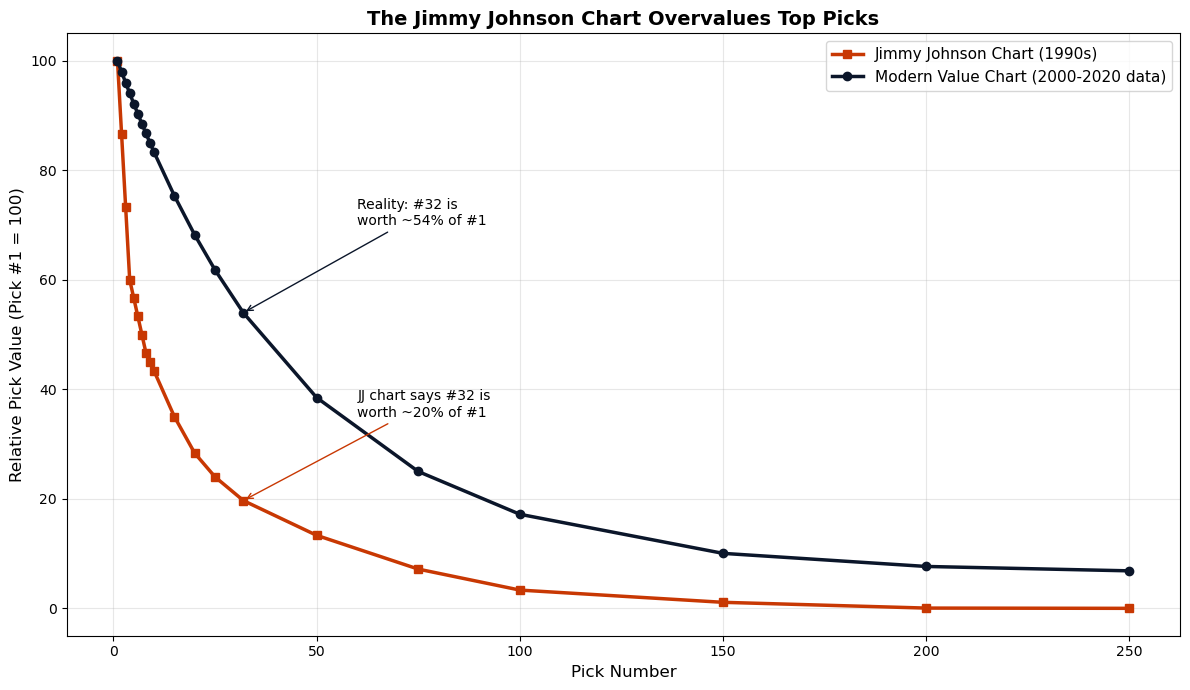


Key comparisons:
  Pick #1 vs #32 — JJ says 5.08x; data says 1.85x
  Pick #1 vs #50 — JJ says 7.50x; data says 2.60x
  Pick #32 vs #100 — JJ says 5.90x; data says 3.14x


In [5]:
# Canonical Jimmy Johnson chart values
jj_chart = {
    1: 3000, 2: 2600, 3: 2200, 4: 1800, 5: 1700, 6: 1600, 7: 1500, 8: 1400, 9: 1350, 10: 1300,
    15: 1050, 20: 850, 25: 720, 32: 590, 50: 400, 75: 215, 100: 100, 150: 33, 200: 1.4, 250: 0
}

jj_picks = list(jj_chart.keys())
jj_normalized = [jj_chart[p] / jj_chart[1] * 100 for p in jj_picks]
our_normalized = [decay_curve(p, a, b, c) / decay_curve(1, a, b, c) * 100 for p in jj_picks]

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(jj_picks, jj_normalized, marker='s', linewidth=2.5, label='Jimmy Johnson Chart (1990s)', color=BEARS_ORANGE)
ax.plot(jj_picks, our_normalized, marker='o', linewidth=2.5, label='Modern Value Chart (2000-2020 data)', color=BEARS_NAVY)
ax.set_xlabel('Pick Number', fontsize=12)
ax.set_ylabel('Relative Pick Value (Pick #1 = 100)', fontsize=12)
ax.set_title('The Jimmy Johnson Chart Overvalues Top Picks', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.annotate('JJ chart says #32 is\nworth ~20% of #1', xy=(32, 19.7), xytext=(60, 35),
            fontsize=10, arrowprops=dict(arrowstyle='->', color=BEARS_ORANGE))
ax.annotate("Reality: #32 is\nworth ~54% of #1", xy=(32, 54), xytext=(60, 70),
            fontsize=10, arrowprops=dict(arrowstyle='->', color=BEARS_NAVY))

plt.tight_layout()
plt.savefig('jj_vs_modern.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey comparisons:")
print(f"  Pick #1 vs #32 — JJ says {jj_chart[1]/jj_chart[32]:.2f}x; data says {decay_curve(1,a,b,c)/decay_curve(32,a,b,c):.2f}x")
print(f"  Pick #1 vs #50 — JJ says {jj_chart[1]/jj_chart[50]:.2f}x; data says {decay_curve(1,a,b,c)/decay_curve(50,a,b,c):.2f}x")
print(f"  Pick #32 vs #100 — JJ says {jj_chart[32]/jj_chart[100]:.2f}x; data says {decay_curve(32,a,b,c)/decay_curve(100,a,b,c):.2f}x")

## 5. Bears Audit: Value Over Expected

Applying the modern curve to every Bears pick, we calculate **Value Over Expected (VOE)** — career value minus what an average pick at that slot returns. Positive VOE means the pick beat its slot; negative means it missed.

In [6]:
# Apply curve to entire draft dataset
draft['expected_value'] = decay_curve(draft['pick'], a, b, c)
draft['value_over_expected'] = draft['career_value'] - draft['expected_value']

# Bears subset
bears = draft[draft['team'] == 'CHI'].copy()

# League-wide ranking
team_voe = draft.groupby('team')['value_over_expected'].sum().sort_values(ascending=False)
bears_rank = team_voe.index.get_loc('CHI') + 1
bears_voe = team_voe['CHI']

print(f"Bears total VOE, 2000-2020: {bears_voe:+.1f}")
print(f"Bears rank: {bears_rank} of {len(team_voe)}")
print(f"\nFull league rankings:")
print(team_voe.to_string())

Bears total VOE, 2000-2020: +10.2
Bears rank: 15 of 35

Full league rankings:
team
BAL    200.001313
DAL    197.068226
PIT    138.225210
KAN    125.144981
NWE    118.589358
NOR     97.437220
CAR     92.623213
SEA     83.578431
SDG     62.715028
GNB     55.130307
SFO     51.893798
ARI     50.226789
IND     46.462930
PHI     24.599796
CHI     10.202845
MIN      3.999655
LAR      0.543696
HOU     -8.847763
LAC     -9.398739
LVR    -25.203066
ATL    -33.009591
NYJ    -43.341663
TEN    -46.677681
NYG    -50.702678
MIA    -52.982385
CIN    -54.317882
BUF    -68.415654
WAS    -79.211725
STL    -85.160336
DEN    -94.194230
DET    -97.266584
TAM   -103.927948
OAK   -115.492021
JAX   -119.973460
CLE   -144.412732


### 5a. Best and Worst Bears Picks

The 10 worst picks are entirely Round 1-2 selections; the 10 best span all seven rounds.

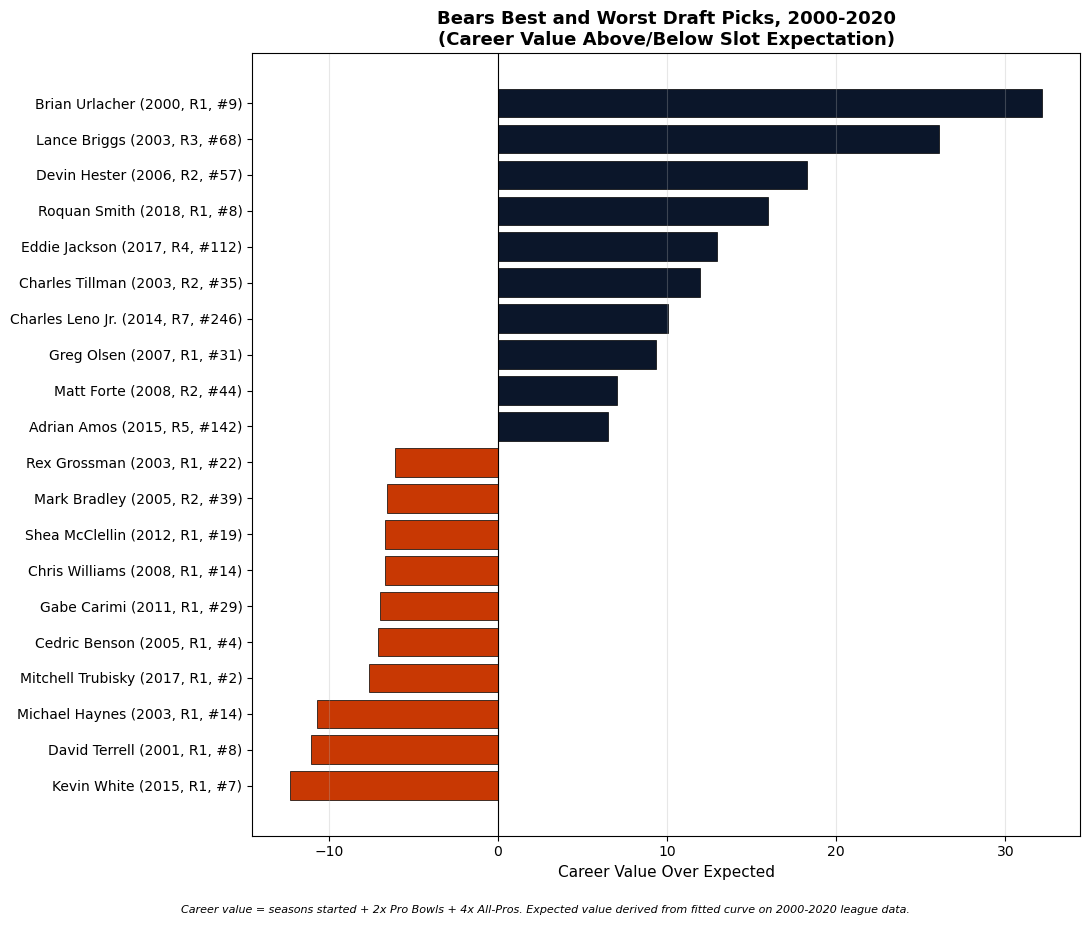

In [7]:
bears_sorted = bears.sort_values('value_over_expected')
worst_10 = bears_sorted.head(10)
best_10 = bears_sorted.tail(10)
combined = pd.concat([worst_10, best_10])

colors = [BEARS_ORANGE if v < 0 else BEARS_NAVY for v in combined['value_over_expected']]
labels = [f"{row['pfr_player_name']} ({row['season']}, R{row['round']}, #{row['pick']})" 
          for _, row in combined.iterrows()]

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(range(len(combined)), combined['value_over_expected'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(combined)))
ax.set_yticklabels(labels, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Career Value Over Expected', fontsize=11)
ax.set_title('Bears Best and Worst Draft Picks, 2000-2020\n(Career Value Above/Below Slot Expectation)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
fig.text(0.5, -0.02, 
         'Career value = seasons started + 2x Pro Bowls + 4x All-Pros. Expected value derived from fitted curve on 2000-2020 league data.',
         ha='center', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('bears_hits_misses.png', dpi=150, bbox_inches='tight')
plt.show()

### 5b. Position Group Breakdown

The Bears' positive aggregate VOE is driven entirely by linebackers and defensive backs. Quarterbacks, wide receivers, and high-round defensive linemen drag the franchise down.

Bears performance by position group:
           picks  total_voe  avg_voe
pos_group                           
DL            24     -38.41    -1.60
WR            23     -34.54    -1.50
QB             7     -15.95    -2.28
RB            13      -3.57    -0.27
OL            24      -3.56    -0.15
ST             2      -1.29    -0.65
TE             7       3.10     0.44
DB            37      51.94     1.40
LB            19      52.48     2.76


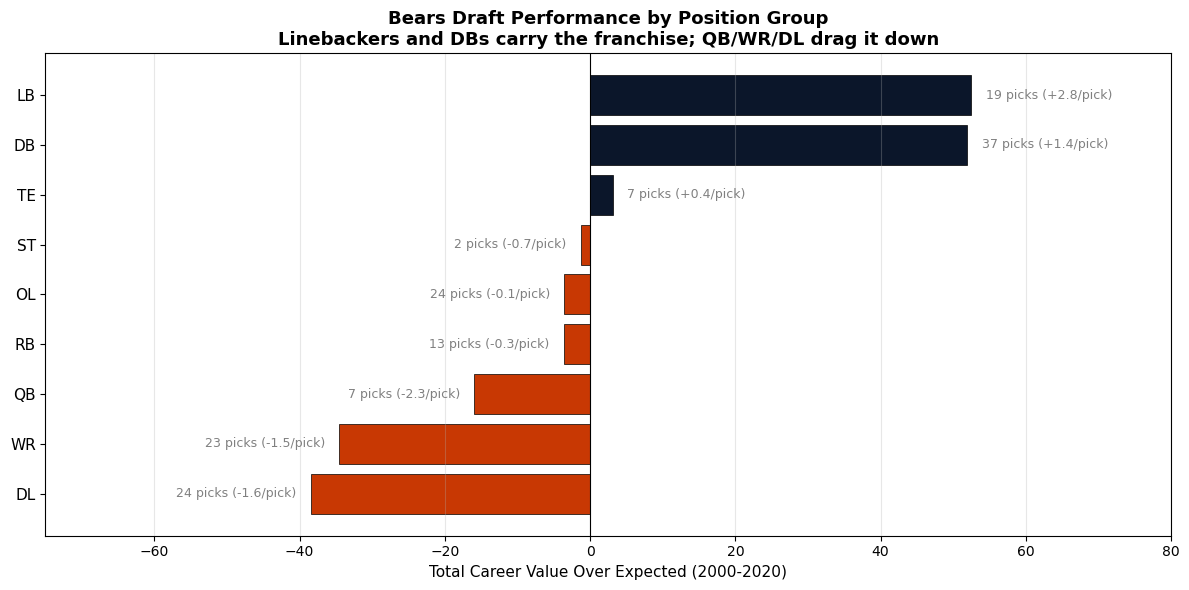

In [8]:
# Standardize position labels (DB family, LB family, etc.)
position_map = {
    'DB': 'DB', 'CB': 'DB', 'S': 'DB',
    'LB': 'LB', 'OLB': 'LB', 'ILB': 'LB',
    'DE': 'DL', 'DT': 'DL', 'NT': 'DL', 'DL': 'DL',
    'T': 'OL', 'G': 'OL', 'C': 'OL', 'OL': 'OL',
    'WR': 'WR', 'RB': 'RB', 'TE': 'TE', 'QB': 'QB',
    'FB': 'RB', 'K': 'ST', 'P': 'ST', 'LS': 'ST',
}

bears['pos_group'] = bears['position'].map(position_map)
bears_by_pos = bears.groupby('pos_group').agg(
    picks=('pick', 'count'),
    total_voe=('value_over_expected', 'sum'),
    avg_voe=('value_over_expected', 'mean')
).round(2).sort_values('total_voe')

print("Bears performance by position group:")
print(bears_by_pos.to_string())

pos_colors = [BEARS_ORANGE if v < 0 else BEARS_NAVY for v in bears_by_pos['total_voe']]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(bears_by_pos)), bears_by_pos['total_voe'], color=pos_colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(bears_by_pos)))
ax.set_yticklabels(bears_by_pos.index, fontsize=11)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Total Career Value Over Expected (2000-2020)', fontsize=11)
ax.set_title("Bears Draft Performance by Position Group\nLinebackers and DBs carry the franchise; QB/WR/DL drag it down",
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(-75, 80)

for i, (idx, row) in enumerate(bears_by_pos.iterrows()):
    label = f"{int(row['picks'])} picks ({row['avg_voe']:+.1f}/pick)"
    if row['total_voe'] >= 0:
        x_pos = row['total_voe'] + 2
        ha = 'left'
    else:
        x_pos = row['total_voe'] - 2
        ha = 'right'
    ax.text(x_pos, i, label, va='center', ha=ha, fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('bears_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

### 5c. GM Era Breakdown

The Bears' three primary 21st-century GMs show different patterns. Pace's positive number is driven by Day 2/3 hits offsetting his Round 1 disasters; Angelo's volume of picks accumulated steady negative value.

In [9]:
def assign_gm(season):
    if season <= 2011:
        return 'Jerry Angelo (2001-2011)'
    elif season <= 2014:
        return 'Phil Emery (2012-2014)'
    else:
        return 'Ryan Pace (2015-2020)'

bears_eras = bears[bears['season'] >= 2001].copy()
bears_eras['gm_era'] = bears_eras['season'].apply(assign_gm)

gm_summary = bears_eras.groupby('gm_era').agg(
    drafts=('season', 'nunique'),
    picks=('pick', 'count'),
    total_voe=('value_over_expected', 'sum'),
    avg_voe_per_pick=('value_over_expected', 'mean')
).round(2)

print("Bears draft performance by GM era:")
print(gm_summary.to_string())

print("\nBest pick per era:")
for era in bears_eras['gm_era'].unique():
    era_picks = bears_eras[bears_eras['gm_era'] == era]
    best = era_picks.nlargest(1, 'value_over_expected').iloc[0]
    print(f"  {era}: {best['pfr_player_name']} (R{best['round']}, #{best['pick']}, VOE {best['value_over_expected']:+.1f})")

print("\nWorst pick per era:")
for era in bears_eras['gm_era'].unique():
    era_picks = bears_eras[bears_eras['gm_era'] == era]
    worst = era_picks.nsmallest(1, 'value_over_expected').iloc[0]
    print(f"  {era}: {worst['pfr_player_name']} (R{worst['round']}, #{worst['pick']}, VOE {worst['value_over_expected']:+.1f})")

Bears draft performance by GM era:
                          drafts  picks  total_voe  avg_voe_per_pick
gm_era                                                              
Jerry Angelo (2001-2011)      11     88     -20.06             -0.23
Phil Emery (2012-2014)         3     20      -6.94             -0.35
Ryan Pace (2015-2020)          6     39       4.42              0.11

Best pick per era:
  Jerry Angelo (2001-2011): Lance Briggs (R3, #68, VOE +26.1)
  Phil Emery (2012-2014): Charles Leno Jr. (R7, #246, VOE +10.0)
  Ryan Pace (2015-2020): Roquan Smith (R1, #8, VOE +15.9)

Worst pick per era:
  Jerry Angelo (2001-2011): David Terrell (R1, #8, VOE -11.1)
  Phil Emery (2012-2014): Shea McClellin (R1, #19, VOE -6.7)
  Ryan Pace (2015-2020): Kevin White (R1, #7, VOE -12.3)


## 6. Findings

The Jimmy Johnson chart overvalues top picks by approximately 2.7x. Pick #1 is worth roughly 1.85x pick #32 in actual outcomes, not 5.08x. This has direct implications for trade-up valuation.

The Bears have drafted slightly above league average (+10.2 cumulative VOE, 15th of 32 teams). Hits like Urlacher, Briggs, Roquan Smith, and Eddie Jackson have offset the high-profile misses.

The Bears' draft DNA is strongly positional. Linebackers and defensive backs combined for +104 VOE; quarterbacks, wide receivers, and high-round defensive linemen for -89. The franchise's edge is in the back seven; the pain has come from premium-position swings at the top of the draft.

## Limitations

The metric undervalues special teams contributors (Devin Hester reads as +18, understated for a Hall of Fame returner). Pro Bowl voting reflects narrative as much as performance. Aggregate VOE rewards volume of small wins; a GM with fewer picks but bigger swings may be undersold. Career value is path-dependent — high picks get longer leashes regardless of performance, which can inflate seasons started.